In [5]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as ps
import torch
#import torch_geometric
import pandas as pd
import torch.nn as nn
import optuna

print(optuna.__version__)
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch, os

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.tri as mtri
import matplotlib.ticker as mticker
from matplotlib.ticker import LogLocator, NullFormatter

from pathlib import Path
from models import CondSM
from scipy.optimize import curve_fit
from sm import NeuralNet
from utils import create_dopant_configuration, current_distribution

print(torch.version.cuda)
print(torch.__version__)

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 14,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 18,    # affects horizontal colorbar ticks
    "ytick.labelsize": 18,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 14,
    "axes.labelsize": 20,
    "legend.fontsize": 14,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

4.4.0
12.6
2.10.0+cu126
cuda


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ecdf_grid_1row_simple(
    func_types,
    data_types,
    scores_txt_template,
    out_pdf,
    data_type_labels=None,
    max_points=50_000,
    figsize=None,
    xscale=None,
    yscale=None,                 # can be "log" or "linear"
    use_ccdf=False,
    ccdf_logy=True,
    global_xlim_quantiles=(0.0, 0.99),
    legend=True,
    seed_for_subsample=0,
):
    rng = np.random.default_rng(seed_for_subsample)

    # labels
    if data_type_labels is None:
        dt2lab = {dt: dt for dt in data_types}
    elif isinstance(data_type_labels, dict):
        dt2lab = {dt: data_type_labels.get(dt, dt) for dt in data_types}
    else:
        dt2lab = dict(zip(data_types, data_type_labels))

    def load_scores(dt, func_type):
        p = scores_txt_template.format(data_type=dt, func_type=func_type)
        s = np.loadtxt(p, dtype=float).ravel()
        s = s[np.isfinite(s)]
        if max_points is not None and s.size > max_points:
            s = rng.choice(s, size=max_points, replace=False)
        return s

    # global x-lims
    all_vals = []
    for ft in func_types:
        for dt in data_types:
            s = load_scores(dt, ft)
            if s.size:
                all_vals.append(s)
    if not all_vals:
        raise RuntimeError("No values loaded. Check scores_txt_template.")
    all_vals = np.concatenate(all_vals)

    lo_q, hi_q = global_xlim_quantiles
    xmin = float(np.quantile(all_vals, lo_q))
    xmax = float(np.quantile(all_vals, hi_q))
    if xmin == xmax:
        xmin, xmax = float(all_vals.min()), float(all_vals.max())

    # decide y scale ONCE
    yscale_final = yscale
    if yscale_final is None and use_ccdf and ccdf_logy:
        yscale_final = "log"
    if yscale_final is None:
        yscale_final = "linear"
    y_is_log = (yscale_final == "log")

    n = len(func_types)
    if figsize is None:
        figsize = (2.6 * n, 2.8)
    fig, axes = plt.subplots(1, n, figsize=figsize, sharex=True)
    if n == 1:
        axes = [axes]

    for k, ft in enumerate(func_types):
        ax = axes[k]

        for dt in data_types:
            s = load_scores(dt, ft)
            if s.size == 0:
                continue

            x = np.sort(s)
            m = x.size
            ecdf = np.arange(1, m + 1) / m

            if use_ccdf:
                y = 1.0 - ecdf
            else:
                y = ecdf

            # log-safe: avoid zeros (works for ECDF or CCDF)
            if y_is_log:
                y = np.clip(y, 1.0 / m, 1.0)

            ax.step(x, y, where="post", lw=1.6, label=dt2lab[dt])

        ax.set_title(str(ft), fontweight="bold")
        ax.set_xlabel(r"Fitness $\mathcal{E}_Z$")
        ax.set_xlim(xmin, xmax)
        ax.grid(True, alpha=0.3)

        if k == 0:
            ax.set_ylabel(r"$1-\mathrm{ECDF}(\mathcal{E}_{\mathrm{aff}})$" if use_ccdf
                          else r"$\mathrm{ECDF}(\mathcal{E}_{\mathrm{aff}})$")
        else:
            ax.tick_params(labelleft=False)

        ax.set_yscale(yscale_final)

        if y_is_log:
            # lower bound: smallest representable step among plotted curves is ~1/m
            ax.set_ylim(1.0 / (max_points if max_points else 100_000), 1.0)
        else:
            ax.set_ylim(0.0, 1.0)

        if xscale is not None:
            ax.set_xscale(xscale)

    if legend:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center",
                   ncol=min(len(labels), 6), frameon=False)

    fig.tight_layout(rect=(0, 0, 1, 0.88 if legend else 1))
    fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.04)
    plt.close(fig)

## mc ecdfs

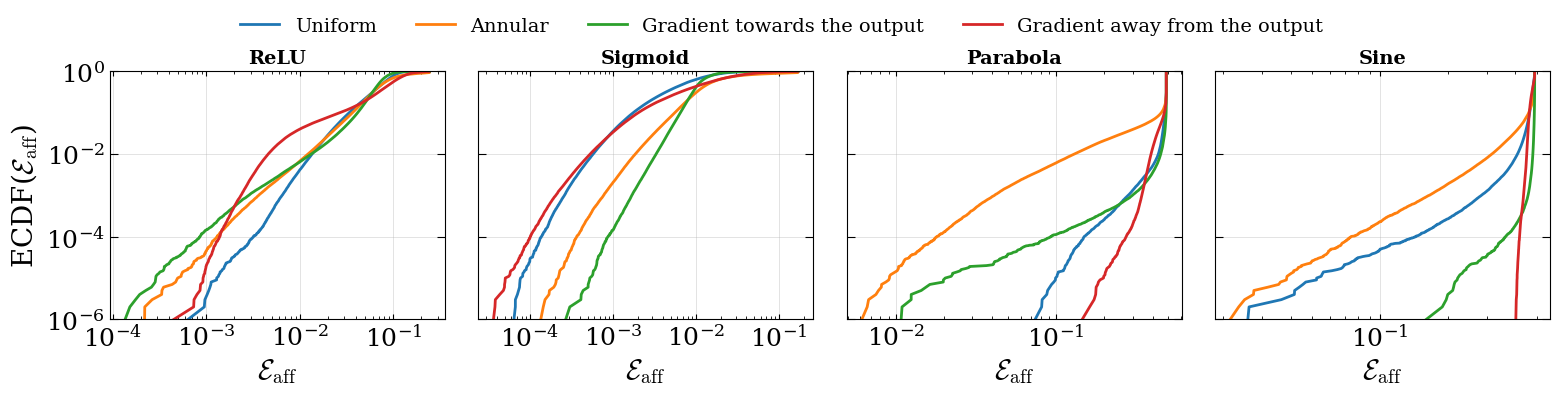

In [9]:
c_v_min, c_v_max = -1.5, 1.5
seed = 42
max_l2 = 2.0
input_index = 3

base = "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse"

scores_txt_template = (
    base
    + "/scores_random_affine_data_type={data_type}_func={func_type}"
    + f"_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_maxl2={max_l2}_input_idx={input_index}.txt"
)

func_types  = ["ReLU", "Sigmoid", "Parabola", "Sine"]  # your 4 targets
#func_types  = ["Linear", "Gaussian", "Cubic", "Cosine"]
data_type_labels = {
    "uni_1e7": "Uniform",
    "data_vMB_ring_1e7": "Annular",
    "grad_towards_1e7": r"Gradient towards the output",
    "grad_away_1e7": r"Gradient away from the output",
}
data_types = ["uni_1e7", "data_vMB_ring_1e7", "grad_towards_1e7", "grad_away_1e7"]

"""plot_ecdf_grid_1row_simple(
    func_types=func_types,
    data_types=data_types,
    scores_txt_template=scores_txt_template,
    out_pdf="mc_ecdfs.pdf",
    data_type_labels=None,
    max_points=1_000_000,
    figsize=None,
    xscale=None,
    yscale='log',
    use_ccdf=False,
    ccdf_logy=True,
    global_xlim_quantiles=(0.0, 1.0),
    legend=True,
    seed_for_subsample=0,
)"""

fig, axs = plt.subplots(ncols=len(func_types), figsize=(4*4, 4))
fig.subplots_adjust(top=0.82, bottom=0.2, left=0.08, right=0.98, wspace=0.1)
    
for j, func in enumerate(func_types):
    for dt, dl in data_type_labels.items():
        scores = np.loadtxt(
            base
            + f"/scores_random_affine_data_type={dt}_func={func}"
            + f"_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_maxl2={max_l2}_input_idx={input_index}.txt"
        )
        #s = s[np.isfinite(scores)]
        s_sorted = np.sort(scores)
        n = len(s_sorted)
        
        ecdf = np.arange(1, n + 1) / n
        ecdf = np.clip(ecdf, 1/n, 1.0)
        
        axs[j].set_ylim(1/n, 1.0)
        axs[j].plot(s_sorted, ecdf, lw=2, label=f'{dl}')
        axs[j].set_title(f'{func}', fontdict={'weight': 'bold'})
        
for i, ax in enumerate(axs):
    # --- scale + locators first ---
    ax.minorticks_on()
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_minor_formatter(NullFormatter())

    # --- now actually draw the minor ticks (force visible length) ---
    ax.minorticks_on()
    ax.tick_params(top=True, right=True, which='both', direction='in')
    ax.tick_params(axis='y', which='major', length=6)
    ax.tick_params(axis='y', which='minor', length=3)  # <- key: make them visible

    # --- grid AFTER locators ---
    ax.grid(lw=0.5, alpha=0.5, which='major', axis='y')
    ax.grid(lw=0.5, alpha=0.3, which='minor', axis='y')
    ax.grid(lw=0.5, alpha=0.5, which='major', axis='x')
    
    ax.set_xlabel(r'$\mathcal{E}_{\mathrm{aff}}$')
    if i == 0:
        ax.set_ylabel(r'ECDF($\mathcal{E}_{\mathrm{aff}}$)')
    else:
        ax.tick_params(labelleft=False)

handles, labels = axs.flat[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.00)
)
fig.savefig(f'ecdfs_mc.pdf')
plt.show()